# Omni-iEEG dataset overview

Overview of the [Omni-iEEG](https://github.com/Omni-iEEG) dataset, loaded through Foundry's `OmniIEEGDataset`
(`foundry/data/datasets/omni_ieeg.py`) and its processing pipeline (`foundry/data/pipelines/omni_ieeg.py`,
invoked via `pipelines/omni_ieeg/pipeline.py`).

Omni-iEEG is a multi-center intracranial EEG dataset for epilepsy research: each recording is a BIDS-style
iEEG run (one EDF file) with channel-level seizure-onset-zone (`soz`) and `resection` labels, plus
patient-level surgical `outcome`.

Note: `data/raw_dir/omni_ieeg` is a local snapshot of the dataset -- `participants.tsv` lists more patients
than currently have EDF files on disk, so the counts below reflect the full registry (`participants.tsv`),
not necessarily what's downloaded locally.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from foundry.data.datasets import OmniIEEGDataset

RAW_DIR = Path("/capstor/scratch/cscs/davalos/data/raw/omni_ieeg")
PROCESSED_DIR = Path("/capstor/scratch/cscs/davalos/data/processed")


/capstor/scratch/cscs/davalos/neurosoft_epilepsy/.venv/lib64/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-08-12 10:40:26,505	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


## 1. Dataset composition

`participants.tsv` lists every patient across Omni-iEEG's constituent sub-datasets (Multicenter, openieeg,
hup, sourcesink, zurich).

In [1]:
participants

NameError: name 'participants' is not defined

In [22]:
participants = pd.read_csv(RAW_DIR / "participants.tsv", sep="\t")
print(f"{len(participants)} participants listed in participants.tsv\n")
participants["dataset"].value_counts()

328 participants listed in participants.tsv



dataset
openieeg       185
hup             58
sourcesink      39
Multicenter     26
zurich          20
Name: count, dtype: int64

In [23]:
participants["outcome"].value_counts().rename(
    index={1: "successful (Engel I)", 0: "unsuccessful (Engel II+)", -1: "unknown"}
)

outcome
successful (Engel I)        196
unsuccessful (Engel II+)    107
unknown                      25
Name: count, dtype: int64

In [24]:
participants["sampling_frequency"].value_counts().sort_index()

sampling_frequency
249.853552       3
256.000000       2
499.000000       1
499.707104       2
500.000000      14
512.000000      30
999.000000       3
999.412111       4
1000.000000    170
1024.000000     21
2000.000000     78
Name: count, dtype: int64

In [25]:
participants["age"].value_counts().sort_index()

age
-1     30
 2      2
 3      2
 4      7
 5     11
 6      6
 7      5
 8     11
 9      8
 10    13
 11    10
 12    13
 13    12
 14    16
 15    10
 16    13
 17    17
 18     4
 19     9
 20    11
 21     7
 22     1
 23     6
 24     5
 25    10
 26     2
 27     3
 28     6
 29     1
 30     5
 31     4
 32     5
 33     3
 34     1
 35     3
 36     7
 37     6
 38     3
 39     5
 40     3
 41     3
 42     3
 43     2
 44     1
 45     3
 46     3
 47     2
 48     4
 49     2
 50     1
 52     3
 56     1
 57     2
 59     1
 62     1
Name: count, dtype: int64

In [26]:
participants["sex"].value_counts().sort_index()

sex
-1      8
 0    152
 1    168
Name: count, dtype: int64

In [27]:
print(participants.columns)

Index(['participant_id', 'age', 'sex', 'resection', 'has_resection',
       'has_anatomical', 'has_soz', 'task', 'outcome', 'methods',
       'sampling_frequency', 'dataset', 'event_annotation',
       'event_annotation_count'],
      dtype='str')


In [28]:
participants["methods"].value_counts().sort_index()

methods
ECOG      9
ECoG    224
MISC      9
SEEG     86
Name: count, dtype: int64

In [29]:
participants["event_annotation"].value_counts().sort_index()

event_annotation
0    279
1     49
Name: count, dtype: int64

In [30]:
participants["has_resection"].value_counts().sort_index()

has_resection
0     31
1    297
Name: count, dtype: int64

In [31]:
participants["resection"].value_counts().sort_index()

resection
-1     31
 0     38
 1    259
Name: count, dtype: int64

## 2. Annotation coverage

Percentage of patients with each type of annotation available. `event_annotation` is the flag that matters
most for downstream event-level tasks (e.g. HFO/seizure detection): only a fraction of patients have raw
annotated events, whereas `soz`/`resection`/`anatomical` channel-level labels are much more broadly available.

In [32]:
annotation_cols = ["has_soz", "has_resection", "has_anatomical", "event_annotation", "sex"]
coverage = pd.DataFrame({
    "n_patients": [int(participants[c].sum()) for c in annotation_cols],
    "pct_of_all_patients": [
        round(100 * participants[c].mean(), 1) for c in annotation_cols
    ],
}, index=annotation_cols)
coverage

,n_patients,pct_of_all_patients
has_soz,288,87.8
has_resection,297,90.5
has_anatomical,107,32.6
event_annotation,49,14.9
sex,160,48.8


In [33]:
pct_event_annotated = 100 * participants["event_annotation"].mean()
n_events = int(participants["event_annotation_count"].sum())
print(
    f"{pct_event_annotated:.1f}% of patients "
    f"({int(participants['event_annotation'].sum())}/{len(participants)}) "
    f"have raw event annotations, totalling {n_events} annotated events."
)

14.9% of patients (49/328) have raw event annotations, totalling 36177 annotated events.


<Axes: xlabel='event_annotation_count', ylabel='Count'>

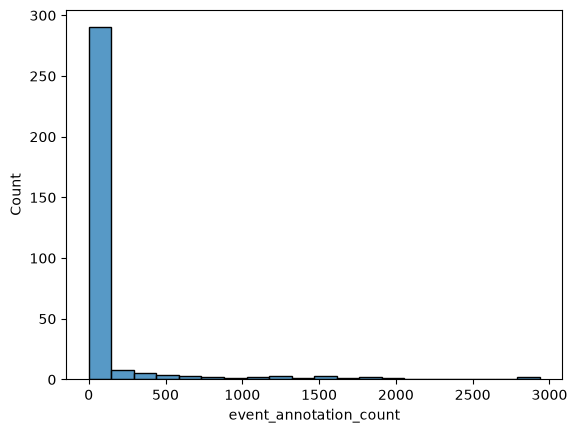

In [34]:
import seaborn as sns
sns.histplot(participants["event_annotation_count"], bins=20)

## 3. Official train/test split

`derivatives/datasplit/final_split.csv` assigns train/test per EDF file (not per patient).

In [35]:
final_split = pd.read_csv(RAW_DIR / "derivatives" / "datasplit" / "final_split.csv")
print(f"{len(final_split)} EDF-level rows in the official split\n")
final_split["split"].value_counts()

#TODO: check the stratification of train test splits

1026 EDF-level rows in the official split



split
train    692
test     334
Name: count, dtype: int64

## 4. Processed recordings via `OmniIEEGDataset`

Only a handful of demo recordings have been processed so far. Run the full pipeline to process every
discovered recording into `data/processed/omni_ieeg/`.

- In parallel mode, brainsets prepare runs each pipeline worker as a Ray actor, and Ray repackages/ships the working   directory to a separate sandbox path (/private/tmp/ray/session_.../working_dir_files/...) — you can see it in the log's
  traceback paths.
  If --raw data/raw_dir is a relative path, so once the Ray worker's CWD is that sandbox copy instead of
  the repo root, data/raw_dir/omni_ieeg/... no longer resolves to the real 27GB dataset.
  This didn't happen in my earlier --single test because that mode runs synchronously in the current process, with no Ray working-dir repackaging involved.

  - the pipeline skips any .h5 that already exists unless --reprocess is passed.
  - This will process all 464 discovered recordings from the 27GB raw dataset — expect it to take a while and produce a large
  data/processed/omni_ieeg/ (each .h5 stores the signal as float64, so e.g. that 67MB sleep EDF became a 282MB .h5; expect the
  full processed set to run well into the multi-GB range).

```bash
  uv run brainsets prepare --local pipelines/omni_ieeg --use-active-env \
      --raw /Users/avalos/Documents/Programming/neurosoft_epilepsy/data/raw_dir \
      --processed-dir /Users/avalos/Documents/Programming/neurosoft_epilepsy/data/processed
```

In [36]:
ds = OmniIEEGDataset(root=str(PROCESSED_DIR))
print(ds)
ds.recording_ids

OmniIEEGDataset(n_recordings=594)


['sub-Multicenterjh101_ses-presurgery_task-ictal_acq-ecog_run-01',
 'sub-Multicenterjh101_ses-presurgery_task-ictal_acq-ecog_run-02',
 'sub-Multicenterjh101_ses-presurgery_task-ictal_acq-ecog_run-03',
 'sub-Multicenterjh101_ses-presurgery_task-ictal_acq-ecog_run-04',
 'sub-Multicenterjh102_ses-presurgery_task-ictal_acq-ecog_run-01',
 'sub-Multicenterjh102_ses-presurgery_task-ictal_acq-ecog_run-02',
 'sub-Multicenterjh102_ses-presurgery_task-ictal_acq-ecog_run-03',
 'sub-Multicenterjh102_ses-presurgery_task-ictal_acq-ecog_run-04',
 'sub-Multicenterjh102_ses-presurgery_task-ictal_acq-ecog_run-05',
 'sub-Multicenterjh102_ses-presurgery_task-ictal_acq-ecog_run-06',
 'sub-Multicenterjh104_ses-presurgery_task-ictal_acq-ecog_run-01',
 'sub-Multicenterjh104_ses-presurgery_task-ictal_acq-ecog_run-02',
 'sub-Multicenterjh104_ses-presurgery_task-ictal_acq-ecog_run-03',
 'sub-Multicenterjh104_ses-presurgery_task-ictal_acq-ecog_run-04',
 'sub-Multicenterjh104_ses-presurgery_task-ictal_acq-ecog_run-

In [37]:
recording_id = "sub-openieegDetroit001_ses-01_task-sleep"
data = ds.get_recording(recording_id)

print(f"Recording: {recording_id}")
print(
    f"Patient outcome: {data.outcome} | dataset: {data.dataset_name} "
    f"| task: {data.task_name} | split: {data.split}"
)
print(
    f"Signal: {data.ieeg.signal.shape[1]} channels x {data.ieeg.signal.shape[0]} "
    f"samples @ {data.ieeg.sampling_rate} Hz"
)

n_channels = len(data.channels.id)
n_soz = int((data.channels.soz == 1).sum())
n_resection = int((data.channels.resection == 1).sum())
n_anat = int((data.channels.anatomical != "-1").sum())
print(f"SOZ channels: {n_soz}/{n_channels}")
print(f"Resected channels: {n_resection}/{n_channels}")
print(f"Channels with an anatomical label: {n_anat}/{n_channels}")

Recording: sub-openieegDetroit001_ses-01_task-sleep
Patient outcome: 1 | dataset: openieeg | task: sleep | split: train
Signal: 116 channels x 304000 samples @ 1000.0 Hz
SOZ channels: 13/116
Resected channels: 18/116
Channels with an anatomical label: 105/116


## 5. Example signal -- 1 patient, 1 channel

Plotting the first 10 seconds of a seizure-onset-zone (SOZ) channel if one is available.

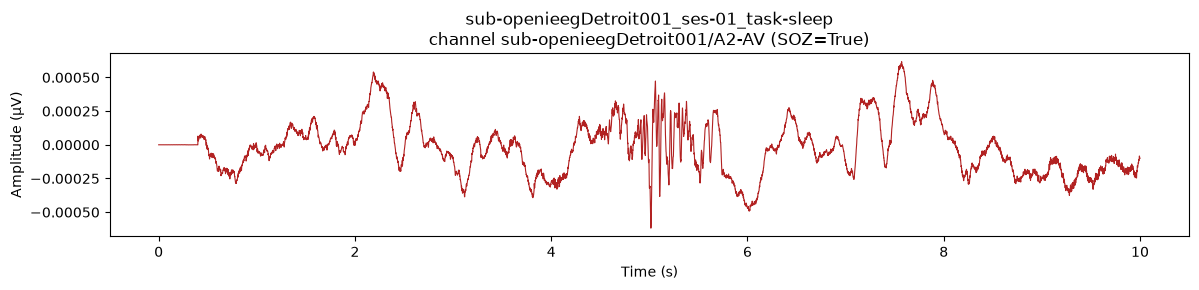

In [38]:
soz_mask = data.channels.soz == 1
channel_idx = int(np.argmax(soz_mask)) if soz_mask.any() else 0
channel_name = data.channels.id[channel_idx]
is_soz = bool(soz_mask[channel_idx])

sample = data.slice(0.0, 10.0)
signal = sample.ieeg.signal[:, channel_idx]
timestamps = sample.ieeg.timestamps

plt.figure(figsize=(12, 3))
plt.plot(timestamps, signal, linewidth=0.8, color="firebrick" if is_soz else "steelblue")
plt.title(f"{recording_id}\nchannel {channel_name} (SOZ={is_soz})")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (\u00b5V)")
plt.tight_layout()
plt.show()

## Next steps

- Run the full pipeline (see command above) to process all discovered recordings, not just this notebook's
  3-recording demo set.
- `nsb-epigrid-v1` (`data/raw_dir/nsb-epigrid-v1`) doesn't have a Foundry dataset/pipeline yet -- once it
  does, it can be added to this notebook alongside Omni-iEEG for a side-by-side comparison.